In [92]:
import numpy as np
import os

file = 'test1.txt'

with open(file, 'r') as f:
    lines = [[float(x) for x in line.strip().split()] for line in f.readlines()]
data1 = np.array(lines)

In [ ]:
from matplotlib import pyplot as plt

# each unique value of data[:, -1] is a different color and different plot
# Extract x, y coordinates from data
x = data1[:, 0]
y = data1[:, 1]

# Get unique values from the last column to use for different colors
unique_values = np.unique(data1[:, -1])
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_values)))

plt.figure(figsize=(10, 8))

# Plot each group with a different color
for i, value in enumerate(unique_values):
    mask = data1[:, -1] == value
    plt.scatter(x[mask], y[mask], s=10, c=[colors[i]], label=f'Value: {value}')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Visualization of Data Points')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


In [94]:
from matplotlib import pyplot as plt
import seaborn as sns
import os
from glob import glob
import numpy as np

success_counts = {
    "mcr":  [],
    "random": [],
    "diffusion_apr25": []
    # "diffusion": []
}

pre_smoothing_lengths = {
    "mcr":  {},
    "random": {},
    "diffusion_apr25": {}
    # "diffusion": {}
}

post_smoothing_lengths = {
    "mcr":  {},
    "random": {},
    "diffusion_apr25": {}
    # "diffusion": {}
}

folder_types = ["mcr", "random", "diffusion_apr25"]
for folder_type in folder_types:    
    folder = f"out/namo_results/many_scenes/{folder_type}"
    files = glob(os.path.join(folder, "*/*.txt"))
    for file in files:
        with open(file, "r") as f:
            lines = f.readlines()
        data = [line.strip().split(",") for line in lines]
        ctr = 0
        name = None
        for line in data:
            if name is None:
                name = line[0]
            if name == "env_config_1" or name == "env_config_4":
                continue
            if name not in pre_smoothing_lengths[folder_type]:
                pre_smoothing_lengths[folder_type][name] = []
            if name not in post_smoothing_lengths[folder_type]:
                post_smoothing_lengths[folder_type][name] = []
            if int(line[1]) == 1:
                ctr += 1
            pre_smoothing_lengths[folder_type][name].append(int(line[2]))
            try:
                post_smoothing_lengths[folder_type][name].append(int(line[3]))
            except:
                post_smoothing_lengths[folder_type][name].append(-1)
        if name == "env_config_1" or name == "env_config_4":
                continue
        success_counts[folder_type].append((name, ctr))

In [ ]:
print(data['mcr'])

In [ ]:
# Create dictionaries for easier access
data = success_counts
mcr_dict = dict(data['mcr'])
random_dict = dict(data['random'])
mcr_random_dict = dict(data['mcr_random'])

# Get unique configurations and sort them
all_configs = sorted(set(config for config, _ in data['mcr'] + data['random'] + data['mcr_random']), 
                     key=lambda x: int(x.split('_')[-1]))

# Prepare the data for plotting
mcr_values = [mcr_dict.get(config, 0) for config in all_configs]
random_values = [random_dict.get(config, 0) for config in all_configs]
mcr_random_values = [mcr_random_dict.get(config, 0) for config in all_configs]
# Setup the plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(all_configs))

# Create the bars
mcr_bars = ax.bar(index - bar_width/3, mcr_values, bar_width, label='MCR', color='blue')
random_bars = ax.bar(index + bar_width/3, random_values, bar_width, label='Random', color='orange')
mcr_random_bars = ax.bar(index + 2*bar_width/3, mcr_random_values, bar_width, label='MCR Random', color='green')

# Add labels, title and axis ticks
ax.set_xlabel('Environment Configuration')
ax.set_ylabel('Success Count')
ax.set_title('Success Counts by Environment Configuration')
ax.set_xticks(index)
ax.set_xticklabels(all_configs)
print(all_configs)
ax.legend()

# Add the values on top of the bars
for i, v in enumerate(mcr_values):
    ax.text(i - bar_width/2, v + 0.2, str(v), ha='center')

for i, v in enumerate(random_values):
    ax.text(i + bar_width/2, v + 0.2, str(v), ha='center')
    
for i, v in enumerate(mcr_random_values):
    ax.text(i + bar_width/2, v + 0.2, str(v), ha='center')

# Add grid lines for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Set y-axis limit to accommodate all values plus a little extra space
ax.set_ylim(0, max(max(mcr_values), max(random_values)) + 1.5)

# Format the x-axis labels to display more clearly
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('mcr_vs_random_success_counts.png')
plt.show()

In [86]:
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Rectangle

# # Data provided by the user
# data = pre_smoothing_lengths
# # {
# #     'mcr': {
# #         'env_config_7': [3, 2, 2, 5, 3, 3, 7, 4, 1, 4], 
# #         'env_config_10': [1, 2, 1, 2, 2, 1, 2, 3, 2, 8], 
# #         'env_config_4': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
# #         'env_config_3': [3, 3, 3, 4, 4, 6, 4, 6, 3, 9], 
# #         'env_config_9': [-1, -1, 10, -1, -1, -1, -1, -1, -1, -1], 
# #         'env_config_1': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
# #         'env_config_6': [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1], 
# #         'env_config_8': [4, 4, 3, 2, 4, -1, 3, 6, 4, 6], 
# #         'env_config_2': [-1, -1, -1], 
# #         'env_config_5': [4, 5, 7, 6, -1, 16, 11, 6, 4, 4]
# #     }, 
# #     'random': {
# #         'env_config_7': [1, 1, 1, 7, 10, 2, 5, 9, 18, 4], 
# #         'env_config_4': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
# #         'env_config_3': [6, 16, 6, -1, 5, -1, 15, 6, 2, 15], 
# #         'env_config_9': [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1], 
# #         'env_config_1': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
# #         'env_config_6': [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1], 
# #         'env_config_10': [2, 4, -1, 10, 4, 2, -1, 2, 14], 
# #         'env_config_8': [-1, -1, -1, -1, -1, 6, 7, -1, 4, 9], 
# #         'env_config_2': [-1, 15, -1, -1, -1, 14, -1, -1, -1, -1], 
# #         'env_config_5': [17, 12, -1, -1, -1, -1, -1, 19, -1, -1]
# #     }
# # }

# # Function to filter out -1 values and calculate stats
# def calculate_stats(values):
#     filtered = [v for v in values if v != -1]
#     if not filtered:
#         return None
    
#     return {
#         'min': min(filtered),
#         'max': max(filtered),
#         'median': np.median(filtered),
#         'q1': np.percentile(filtered, 25),
#         'q3': np.percentile(filtered, 75),
#         'count': len(filtered)
#     }

# # Get all unique environment configurations
# all_configs = sorted(set(list(data['mcr'].keys()) + list(data['random'].keys())),
#                      key=lambda x: int(x.split('_')[-1]))

# # Calculate statistics for each configuration
# mcr_stats = {}
# random_stats = {}

# for config in all_configs:
#     if config in data['mcr']:
#         mcr_stats[config] = calculate_stats(data['mcr'][config])
    
#     if config in data['random']:
#         random_stats[config] = calculate_stats(data['random'][config])

# # Set up the plot
# fig, ax = plt.subplots(figsize=(14, 8))
# bar_width = 0.35
# index = np.arange(len(all_configs))

# # Colors
# mcr_color = 'blue'
# random_color = 'orange'

# # Draw candlestick-like plots
# for i, config in enumerate(all_configs):
#     # MCR data
#     if config in mcr_stats and mcr_stats[config]:
#         stats = mcr_stats[config]
        
#         # Box (Q1 to Q3)
#         box_height = stats['q3'] - stats['q1']
#         box = Rectangle((i - bar_width/2 - 0.15, stats['q1']), 0.3, box_height, 
#                          fill=True, color=mcr_color, alpha=0.6)
#         ax.add_patch(box)
        
#         # Median line
#         ax.plot([i - bar_width/2 - 0.15, i - bar_width/2 + 0.15], 
#                 [stats['median'], stats['median']], 
#                 color='black', linewidth=2)
        
#         # Min and Max whiskers
#         ax.plot([i - bar_width/2, i - bar_width/2], 
#                 [stats['min'], stats['q1']], 
#                 color=mcr_color, linewidth=1.5)
#         ax.plot([i - bar_width/2, i - bar_width/2], 
#                 [stats['q3'], stats['max']], 
#                 color=mcr_color, linewidth=1.5)
        
#         # Caps on whiskers
#         ax.plot([i - bar_width/2 - 0.1, i - bar_width/2 + 0.1], 
#                 [stats['min'], stats['min']], 
#                 color=mcr_color, linewidth=1.5)
#         ax.plot([i - bar_width/2 - 0.1, i - bar_width/2 + 0.1], 
#                 [stats['max'], stats['max']], 
#                 color=mcr_color, linewidth=1.5)
    
#     # Random data
#     if config in random_stats and random_stats[config]:
#         stats = random_stats[config]
        
#         # Box (Q1 to Q3)
#         box_height = stats['q3'] - stats['q1']
#         box = Rectangle((i + bar_width/2 - 0.15, stats['q1']), 0.3, box_height, 
#                          fill=True, color=random_color, alpha=0.6)
#         ax.add_patch(box)
        
#         # Median line
#         ax.plot([i + bar_width/2 - 0.15, i + bar_width/2 + 0.15], 
#                 [stats['median'], stats['median']], 
#                 color='black', linewidth=2)
        
#         # Min and Max whiskers
#         ax.plot([i + bar_width/2, i + bar_width/2], 
#                 [stats['min'], stats['q1']], 
#                 color=random_color, linewidth=1.5)
#         ax.plot([i + bar_width/2, i + bar_width/2], 
#                 [stats['q3'], stats['max']], 
#                 color=random_color, linewidth=1.5)
        
#         # Caps on whiskers
#         ax.plot([i + bar_width/2 - 0.1, i + bar_width/2 + 0.1], 
#                 [stats['min'], stats['min']], 
#                 color=random_color, linewidth=1.5)
#         ax.plot([i + bar_width/2 - 0.1, i + bar_width/2 + 0.1], 
#                 [stats['max'], stats['max']], 
#                 color=random_color, linewidth=1.5)

# # Add labels, title and axis ticks
# ax.set_xlabel('Environment Configuration')
# ax.set_ylabel('Number of Steps')
# ax.set_title('Distribution of Steps by Environment Configuration (MCR vs Random)')
# ax.set_xticks(index)
# ax.set_xticklabels(all_configs)

# # Create legend
# mcr_patch = plt.Rectangle((0,0),1,1, color=mcr_color, alpha=0.6)
# random_patch = plt.Rectangle((0,0),1,1, color=random_color, alpha=0.6)
# ax.legend([mcr_patch, random_patch], ['MCR', 'Random'])

# # Add grid lines for better readability
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# # Add sample count text
# for i, config in enumerate(all_configs):
#     mcr_count = mcr_stats.get(config, {}).get('count', 0)
#     random_count = random_stats.get(config, {}).get('count', 0)
    
#     if mcr_count > 0:
#         max_val = mcr_stats[config]['max']
#         ax.text(i - bar_width/2, max_val + 0.5, f"n={mcr_count}", ha='center', va='bottom', color=mcr_color)
    
#     if random_count > 0:
#         max_val = random_stats[config]['max']
#         ax.text(i + bar_width/2, max_val + 0.5, f"n={random_count}", ha='center', va='bottom', color=random_color)

# # Format the x-axis labels to display more clearly
# plt.xticks(rotation=45)
# plt.tight_layout()

# plt.savefig('mcr_vs_random_candlestick.png')
# plt.show()

In [ ]:
# Convert to long-form DataFrame for seaborn
import pandas as pd
data = pre_smoothing_lengths
rows = []
for method in ['mcr', 'random', 'mcr_random']:
    for config, values in data[method].items():
        for val in values:
            if val != -1:  # Ignore -1 values
                rows.append({
                    'method': method,
                    'config': config,
                    'steps': val
                })

df = pd.DataFrame(rows)

# Sort configs by their numeric value
config_order = sorted(df['config'].unique(), key=lambda x: int(x.split('_')[-1]))

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='config', y='steps', hue='method', data=df, order=config_order, 
            palette={'mcr': 'blue', 'random': 'orange', 'mcr_random': 'green'})

color = {
    'mcr': 'blue',
    'random': 'orange',
    'mcr_random': 'green'
}
# Add sample size annotations
for i, config in enumerate(config_order):
    for j, method in enumerate(['mcr', 'random', 'mcr_random']):
        config_method_data = df[(df['config'] == config) & (df['method'] == method)]
        count = len(config_method_data)
        if count > 0:
            max_val = config_method_data['steps'].max()
            plt.text(i + (j-0.75)*0.3, max_val + 0.5, f"n={count}", 
                     ha='center', color=color[method])

plt.title('Distribution of Pushes by Environment Configuration (MCR vs Random vs Diffusion)')
plt.xlabel('Environment Configuration')
plt.ylabel('Number of Pushes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mcr_vs_random_boxplot_seaborn.png')
plt.show()

In [ ]:
# Convert to long-form DataFrame for seaborn
data = post_smoothing_lengths
rows = []
for method in ['mcr', 'random']:
    for config, values in data[method].items():
        for val in values:
            if val != -1:  # Ignore -1 values
                rows.append({
                    'method': method,
                    'config': config,
                    'steps': val
                })

df = pd.DataFrame(rows)

# Sort configs by their numeric value
config_order = sorted(df['config'].unique(), key=lambda x: int(x.split('_')[-1]))

# Create the plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='config', y='steps', hue='method', data=df, order=config_order, 
            palette={'mcr': 'blue', 'random': 'orange'})

# Add sample size annotations
for i, config in enumerate(config_order):
    for j, method in enumerate(['mcr', 'random']):
        config_method_data = df[(df['config'] == config) & (df['method'] == method)]
        count = len(config_method_data)
        if count > 0:
            max_val = config_method_data['steps'].max()
            plt.text(i + (j-0.5)*0.3, max_val + 0.5, f"n={count}", 
                     ha='center', color='blue' if method == 'mcr' else 'orange')

plt.title('Distribution of Pushes by Environment Configuration (MCR vs Random)')
plt.xlabel('Environment Configuration')
plt.ylabel('Number of Pushes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mcr_vs_random_boxplot_seaborn.png')
plt.show()

In [ ]:
from glob import glob
import os
import json
from tqdm import tqdm
file_count_per_env = 5
ktamp_data = "/common/users/dm1487/namo_data/apr21/fixed_start_fixed_goal_many_env"
files = glob(os.path.join(ktamp_data, "*.json"))
# '_'.join(files[0].split("/")[-1].split("_")[4:7])
config_counts = {}
dp_counts = {}
files_per_env = {}
for file in tqdm(files):
    with open(file, "r") as f:
        data = json.load(f)
    
    config = '_'.join(file.split("/")[-1].split("_")[4:7])
    config_counts[config] = config_counts.get(config, 0) + 1
    if config not in files_per_env.keys():
        files_per_env[config] = []
    if len(files_per_env[config]) < file_count_per_env:
        files_per_env[config].append(file)
    for dp in data['data_points']:
        if 'action' in dp.keys():
            dp_counts[config] = dp_counts.get(config, 0) + 1

config_counts, dp_counts

In [ ]:
files_per_env

In [ ]:
import os
import shutil

new_folder = "/common/users/dm1487/namo_data/apr30/fixed_start_fixed_goal_many_env_5_example"
shutil.rmtree(new_folder)
os.makedirs(new_folder, exist_ok=True)
# copy_files = []
# for file in tqdm(files):
#     with open(file, "r") as f:
#         data = json.load(f)
#     config = '_'.join(file.split("/")[-1].split("_")[4:7])
#     config_counts[config] = config_counts.get(config, 0) + 1
#     if config not in one_file_per_env.keys():
#         one_file_per_env[config] = file
        
for config in files_per_env.keys():
    for file in files_per_env[config]:
        shutil.copy(file, os.path.join(new_folder, file.split("/")[-1]))
len(os.listdir(new_folder))


In [ ]:
from matplotlib import pyplot as plt
plt.bar(config_counts.keys(), config_counts.values(), width=0.5)
plt.xticks(rotation=45)

In [ ]:
from matplotlib import pyplot as plt
plt.bar(dp_counts.keys(), dp_counts.values(), width=0.5)
plt.xticks(rotation=45)

In [ ]:
for config in config_counts.keys():
    if config in dp_counts.keys():
        print(config, dp_counts[config]/config_counts[config])

In [ ]:
total_dp = 0
for config in dp_counts.keys():
    total_dp += dp_counts[config]
total_dp

In [ ]:
from glob import glob
import os
data = "out/namo_results/many_scenes/diffusion_apr25/env_config_2"
files = glob(os.path.join(data, "*.txt"))
total_counts = {}
success_counts = {}
pre_smoothing_lengths = {}
for file in files:
    method = '_'.join(file.split("/")[-1].split(".")[0].split("_")[1:])
    with open(file, "r") as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip().split(",")
        if method not in success_counts.keys():
            total_counts[method] = 0
            success_counts[method] = 0
            pre_smoothing_lengths[method] = []
        if int(line[1]) == 1:
            success_counts[method] += 1
            pre_smoothing_lengths[method].append(int(line[2]))
        total_counts[method] += 1
        
# success_counts, pre_smoothing_lengths


In [ ]:
success_counts, total_counts

In [ ]:
# one bar plot of success counts
from matplotlib import pyplot as plt

plt.figure(figsize=(20, 8))
plt.bar(success_counts.keys(), [success_counts[k]/total_counts[k] for k in success_counts.keys()])
plt.title("Success Rate by Method")
plt.ylabel("Success Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)

# # box plot of pre-smoothing lengths
# plt.figure() 
# plt.boxplot([pre_smoothing_lengths[k] for k in pre_smoothing_lengths.keys()], labels=pre_smoothing_lengths.keys())
# plt.title("Pre-smoothing Path Lengths by Method")
# plt.ylabel("Path Length")
# plt.xticks(rotation=45)



In [ ]:
# Create violin plot of pre-smoothing lengths
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convert data to long format for plotting
data = []
for method, lengths in pre_smoothing_lengths.items():
    data.extend([(method, length) for length in lengths])

df = pd.DataFrame(data, columns=['method', 'steps'])

# Create violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='method', y='steps', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Path Lengths by Method')
plt.xlabel('Method')
plt.ylabel('Number of Steps')
plt.tight_layout()
plt.show()

# give me a different plot of pre-smoothing lengths
plt.figure(figsize=(20, 10))
sns.boxplot(x='method', y='steps', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Path Lengths by Method')
plt.xlabel('Method')
plt.ylabel('Number of Steps')
plt.tight_layout()
plt.show()

In [82]:
import numpy as np
import os
from matplotlib import pyplot as plt

pth = "/common/users/dm1487/namo_data/images/may12/random_start_random_goal_many_env/sequence_20250512_164725_c69747_env_config_18_iter2_20250512_164753_ilab1.cs.rutgers.edu_0_dp000003.npz"

data = np.load(pth)


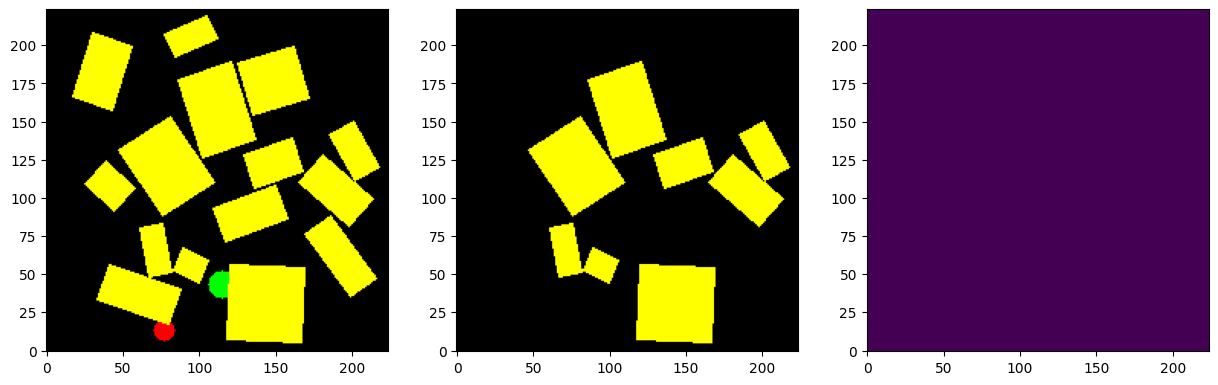

In [83]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(data['scene'])
ax[0].invert_yaxis()
ax[1].imshow(data['reachable_objects_image'])
ax[1].invert_yaxis()
ax[2].imshow(data['object_mask'] + data['goal_mask'])
ax[2].invert_yaxis()

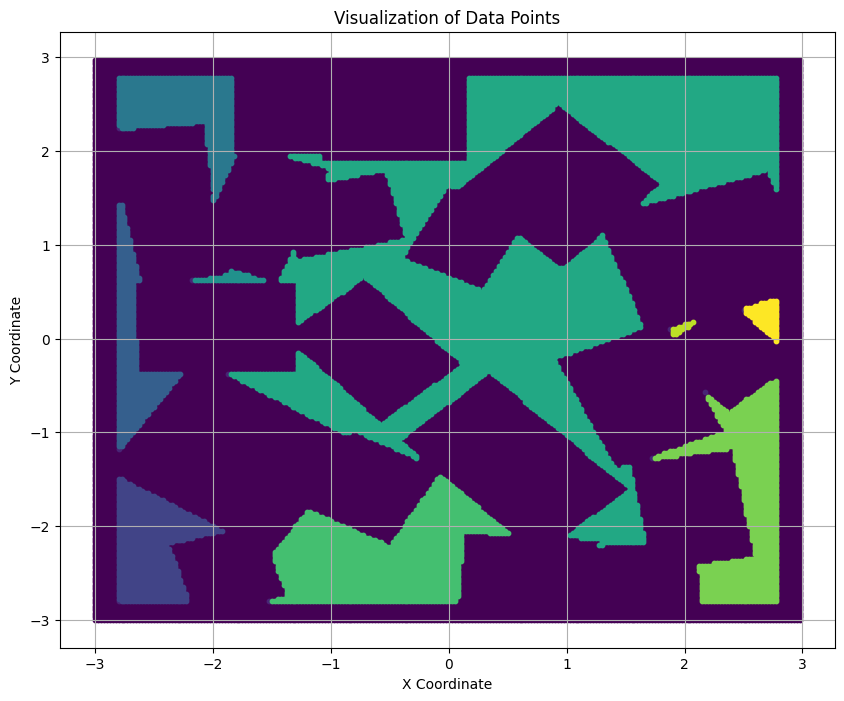

In [75]:
from matplotlib import pyplot as plt


import numpy as np
import os

file = 'sol_wavefronts/1/wavefront_data_2.txt'

with open(file, 'r') as f:
    lines = [[float(x) for x in line.strip().split()] for line in f.readlines()]
data1 = np.array(lines)

# each unique value of data[:, -1] is a different color and different plot
# Extract x, y coordinates from data
x = data1[:, 0]
y = data1[:, 1]

# Get unique values from the last column to use for different colors
unique_values = np.unique(data1[:, -1])
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_values)))

plt.figure(figsize=(10, 8))
# Plot each group with a different color
for i, value in enumerate(unique_values):
    mask = data1[:, -1] == value
    plt.scatter(x[mask], y[mask], s=10, c=[colors[i]], label=f'Value: {value}')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Visualization of Data Points')
# plt.legend(loc='lower left')
plt.grid(True)
plt.show()


In [ ]:
plt